# Pratiksha Somnath Avhad
## Data Analytics – Level 2
### Task 1: Predicting House Prices with Linear Regression


**Objective:**  
To build a Machine Learning model using Linear Regression to predict house prices based on different housing features.

**Tools & Technologies:**  
Python | Pandas | NumPy | Matplotlib | Seaborn | Scikit-learn | Jupyter Notebook

**Project Overview:**  
In this task, I will explore a housing dataset, perform data cleaning and visualization, identify important features,
train a Linear Regression model, and evaluate its performance using suitable regression metrics.

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the housing dataset
df = pd.read_csv("train.csv")

# Display first five rows
print("First 5 rows of the dataset:")
display(df.head())


First 5 rows of the dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### **Observation 1: Dataset Loading**
- The dataset was loaded successfully.
- The first five rows provide an overview of the housing features.
- `SalePrice` is the target variable for prediction.

In [2]:

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False).head(15))

print("\nStatistical Summary:")
display(df.describe())


Dataset Shape: (1460, 81)

Column Names:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPo

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### **Observation 2: Dataset Overview**
- The dataset contains housing features and the `SalePrice` target column.
- Missing values and data types were inspected.
- Statistical summary helps us understand the numerical features.

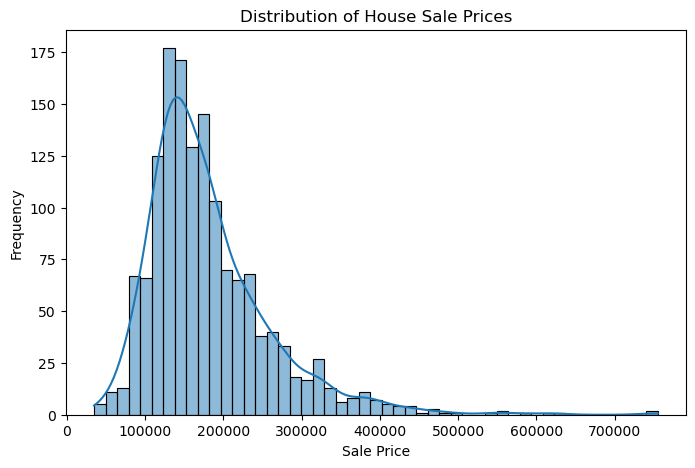

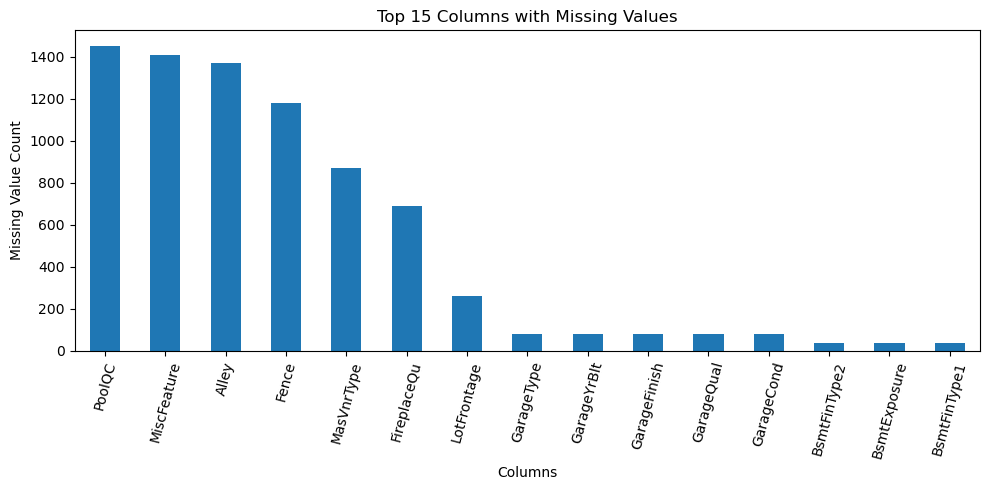

In [3]:
# 1. Distribution of SalePrice
plt.figure(figsize=(8, 5))
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of House Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")
plt.show()

# 2. Top 15 columns with missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
missing_values.plot(kind="bar")
plt.title("Top 15 Columns with Missing Values")
plt.xlabel("Columns")
plt.ylabel("Missing Value Count")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

### **Observation 3: Data Visualization**
- Sale prices are right-skewed, with most houses priced around 100,000–200,000.
- Several columns contain missing values, especially `PoolQC`, `MiscFeature`, and `Alley`.
- Missing values must be handled before model training.

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,YearBuilt,SalePrice
0,7,1710,2,856,2,2003,208500
1,6,1262,2,1262,2,1976,181500
2,7,1786,2,920,2,2001,223500
3,7,1717,3,756,1,1915,140000
4,8,2198,3,1145,2,2000,250000


Correlation with SalePrice:


,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
TotalBsmtSF,0.613581
FullBath,0.560664
YearBuilt,0.522897


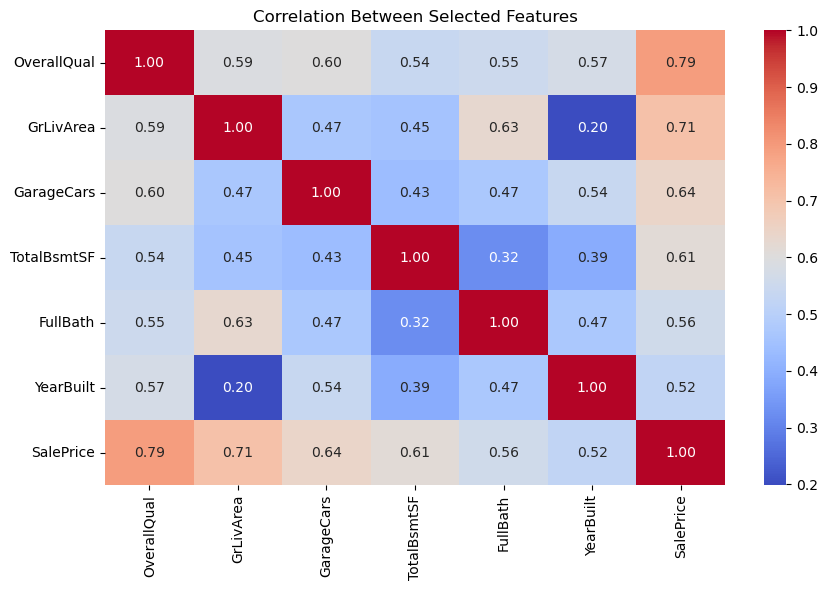

In [4]:
# Select important numerical features
selected_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "YearBuilt",
    "SalePrice"
]

# Display selected features
display(df[selected_features].head())

# Correlation with SalePrice
correlation = df[selected_features].corr()

print("Correlation with SalePrice:")
display(correlation[["SalePrice"]].sort_values(
    by="SalePrice", ascending=False
))

# Correlation heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Selected Features")
plt.tight_layout()
plt.show()

### **Observation 4: Feature Selection and Correlation**
- `OverallQual` has the strongest correlation with `SalePrice` (0.79).
- `GrLivArea` and `GarageCars` also show strong positive correlations.
- These features may help predict house prices.

In [5]:

# Separate features (X) and target variable (y)

X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

# Display shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Display first five rows of features
display(X.head())

# Display first five values of target
display(y.head())


Features shape: (1460, 80)
Target shape: (1460,)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

### **Observation 5: Features and Target Variable**
- The dataset contains 1460 records and 80 input features.
- `SalePrice` is selected as the target variable.
- The features will be used to predict house prices.


In [6]:

# Check missing values in features

missing_values = X.isnull().sum()

# Display columns with missing values
missing_values = missing_values[missing_values > 0].sort_values(
    ascending=False
)

print("Columns with Missing Values:")
display(missing_values)

print("\nTotal missing values in X:", X.isnull().sum().sum())


Columns with Missing Values:


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


Total missing values in X: 7829



### **Observation 6: Missing Values Analysis**
- The dataset contains 7829 missing values across 19 columns.
- `PoolQC`, `MiscFeature`, and `Alley` have the highest number of missing values.
- Missing values must be handled before training the model.


In [7]:

from sklearn.impute import SimpleImputer

# Separate numerical and categorical columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

# Handle missing values in numerical columns
num_imputer = SimpleImputer(strategy="median")
X[numerical_cols] = num_imputer.fit_transform(X[numerical_cols])

# Handle missing values in categorical columns
cat_imputer = SimpleImputer(strategy="most_frequent")
X[categorical_cols] = cat_imputer.fit_transform(X[categorical_cols])

# Check remaining missing values
print("Total missing values after imputation:", X.isnull().sum().sum())


Total missing values after imputation: 0



### **Observation 7: Handling Missing Values**
- Missing values were handled using median and most frequent value imputation.
- Numerical columns were filled with their median values.
- Categorical columns were filled with their most frequent values.


In [8]:

# Convert categorical features into numerical values
X = pd.get_dummies(X, drop_first=True, dtype=int)

print("Shape after encoding:", X.shape)
print("Remaining missing values:", X.isnull().sum().sum())

display(X.head())


Shape after encoding: (1460, 245)
Remaining missing values: 0


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1.0,60.0,65.0,8450.0,7.0,5.0,2003.0,2003.0,196.0,706.0,...,0,0,0,0,1,0,0,0,1,0
1,2.0,20.0,80.0,9600.0,6.0,8.0,1976.0,1976.0,0.0,978.0,...,0,0,0,0,1,0,0,0,1,0
2,3.0,60.0,68.0,11250.0,7.0,5.0,2001.0,2002.0,162.0,486.0,...,0,0,0,0,1,0,0,0,1,0
3,4.0,70.0,60.0,9550.0,7.0,5.0,1915.0,1970.0,0.0,216.0,...,0,0,0,0,1,0,0,0,0,0
4,5.0,60.0,84.0,14260.0,8.0,5.0,2000.0,2000.0,350.0,655.0,...,0,0,0,0,1,0,0,0,1,0



### **Observation 8: Encoding Categorical Features**
- Categorical features were converted into numerical format using one-hot encoding.
- The dataset now contains 1460 rows and 245 columns.
- No missing values remain in the processed features.


In [9]:

from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Display shapes
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)


Training features shape: (1168, 245)
Testing features shape: (292, 245)
Training target shape: (1168,)
Testing target shape: (292,)



### **Observation 9: Train-Test Split**
- The dataset was split into 80% training data and 20% testing data.
- 1168 records were used for training and 292 for testing.
- The training data will be used to build the model, while the testing data will evaluate its performance.


In [10]:

from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")


Linear Regression model trained successfully!



### **Observation 10: Linear Regression Model Training**
- A Linear Regression model was initialized and trained using the training dataset.
- The model learned relationships between house features and sale prices.
- The trained model is ready for prediction and evaluation.


In [11]:

# Predict house prices using the trained model
y_pred = model.predict(X_test)

# Display actual and predicted prices
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

display(comparison.head())


,Actual Price,Predicted Price
0,154500,157784.948994
1,325000,349289.180579
2,115000,86449.665051
3,159000,174007.557439
4,315500,317396.249840



### **Observation 11: House Price Prediction**
- The Linear Regression model predicted house prices using the testing dataset.
- Actual and predicted prices show some differences.
- These predictions will be evaluated using performance metrics.


In [12]:

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Display evaluation results
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Mean Squared Error (MSE):", round(mse, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
print("R2 Score:", round(r2, 4))


Mean Absolute Error (MAE): 20232.18
Mean Squared Error (MSE): 2642483715.19
Root Mean Squared Error (RMSE): 51405.09
R2 Score: 0.6555



### **Observation 12: Model Evaluation**
- The model achieved an R² score of 0.6555.
- The Mean Absolute Error (MAE) is 20232.18.
- The RMSE is 51405.09, indicating prediction errors.
- The model explains approximately 65.55% of the variation in house prices.


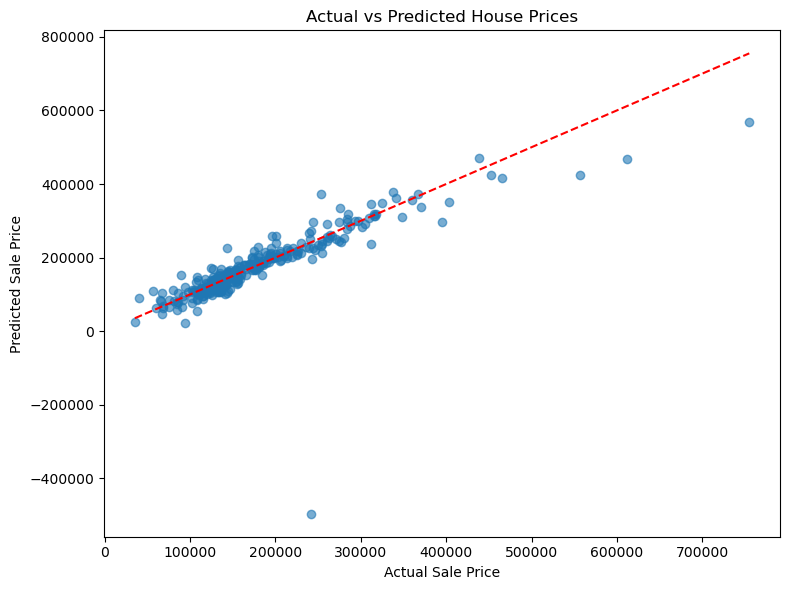

In [13]:

# Visualize actual vs predicted house prices

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

# Add reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.tight_layout()
plt.show()


### **Observation 13: Actual vs Predicted House Prices**

- The scatter plot compares actual and predicted house prices.
- Points closer to the reference line indicate more accurate predictions.
- Differences between actual and predicted values represent prediction errors.


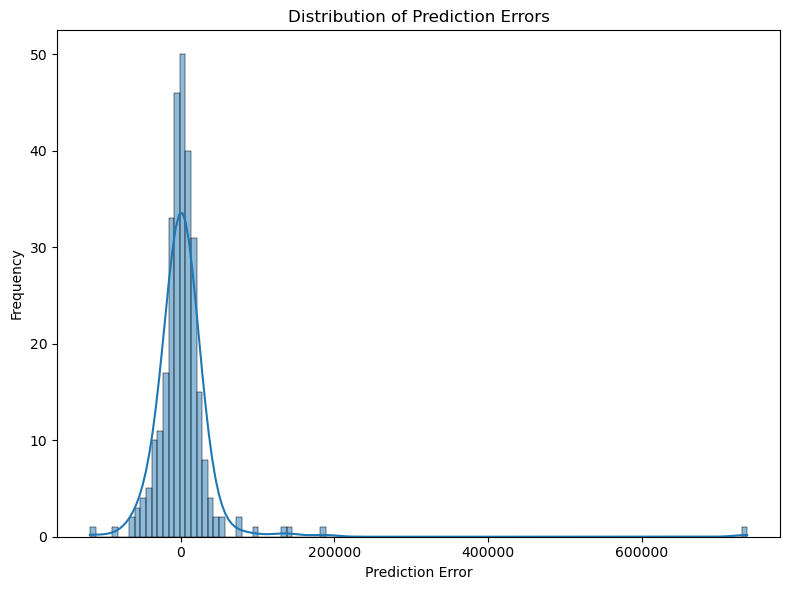

In [14]:
# Calculate prediction errors (residuals)
residuals = y_test - y_pred

# Plot residual distribution
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True)

plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

plt.tight_layout()
plt.show()

### **Observation 14: Residual Analysis**

- The histogram shows the distribution of prediction errors made by the Linear Regression model.
- Residuals represent the differences between actual and predicted house prices.
- This analysis helps us understand how the model's prediction errors are distributed.

## **Project Conclusion**

- The House Price Prediction project was completed using Python and Machine Learning.
- The dataset was cleaned, missing values were handled, and categorical features were encoded.
- A Linear Regression model was trained to predict house prices.
- The model achieved an R² score of **0.6555**, explaining approximately 65.55% of the variation in house prices in the
  test dataset.
- This project helped demonstrate data preprocessing, model training, prediction, and evaluation techniques.